# Notebook 6: Hierarchical Bayesian Scoring Refinement
## What Is a "Perfect" Signing? — Extension

This notebook tests whether a genuine improvement over the flat k=10 shrinkage constant 
(Notebook 4) exists — first via a quick heterogeneity check, then via a properly-specified 
hierarchical Bayesian model. Following the project's standing discipline: any replacement is 
kept only if it demonstrably improves out-of-sample predictive validity over the current 
r=0.526 baseline. Every step is tested, validated, and visualized before moving to the next.

**Requires:** `notebook4_scoring_outfield_final_adjusted.parquet` (or equivalent team-and-age-
adjusted table from Notebook 4), `player_career.parquet`

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import psutil

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222", "axes.titleweight": "bold", "axes.titlesize": 14,
    "axes.labelsize": 11, "xtick.color": "#333333", "ytick.color": "#333333",
    "font.family": "sans-serif", "font.size": 10.5, "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
sns.set_style("whitegrid", {"axes.edgecolor": "#333333"})

PALETTE = {
    "primary": "#1B4332", "secondary": "#D4A24C", "highlight": "#B3452C",
    "neutral": "#5B6B73", "light": "#CFE0E8",
}
pd.set_option("display.max_columns", 50)

# Reload the team-and-age-adjusted outfield table from Notebook 4
scoring_outfield = pd.read_parquet("data/processed/notebook4_signing_score_final.parquet")
player_career = pd.read_parquet("data/processed/player_career.parquet")

print("Reloaded shapes:")
print(f"  scoring_outfield: {scoring_outfield.shape}")
print(f"  player_career: {player_career.shape}")
print(f"\nColumns in scoring_outfield:", scoring_outfield.columns.tolist())
print(f"\nAvailable RAM: {psutil.virtual_memory().available/1e9:.1f} GB")

Reloaded shapes:
  scoring_outfield: (7511, 32)
  player_career: (5536, 12)

Columns in scoring_outfield: ['player_id', 'player', 'league', 'season', 'obv_total_net', 'n_matches', 'pressure_count', 'recovery_count', 'miscontrol_count', 'under_pressure_count', 'obv_per90', 'pressure_per90', 'recovery_per90', 'miscontrol_per90', 'team', 'points', 'matches_played', 'team_ppg', 'obv_predicted_from_team', 'obv_residual', 'primary_position', 'birth_date', 'position_group', 'season_year', 'age', 'age_expected_obv', 'age_expected_baseline', 'age_adjustment', 'obv_team_and_age_adjusted', 'prior_mean', 'obv_shrunk', 'signing_score']

Available RAM: 2.5 GB


## 1. Quick Check: Does Shrinkage Need Differ by Position?

**Purpose:** before building a full hierarchical model, confirm there's genuine heterogeneity 
worth modeling — checking whether the OPTIMAL shrinkage strength plausibly differs across a 
few representative position groups, using a coarse, fast search (not the final method).

In [2]:
def test_shrinkage_k_by_position(k, position, data, transition_pairs):
    pos_data = data[data["primary_position"]==position]
    correlations = []
    for s1, s2 in transition_pairs:
        s1_data = pos_data[pos_data["season"]==s1][["player_id","obv_residual","n_matches","prior_mean"]].copy()
        s1_data["shrunk"] = (s1_data["n_matches"]*s1_data["obv_residual"] + k*s1_data["prior_mean"]) / (s1_data["n_matches"]+k)
        s2_data = pos_data[pos_data["season"]==s2][["player_id","obv_residual"]].rename(columns={"obv_residual":"next_season_obv"})
        merged = s1_data.merge(s2_data, on="player_id", how="inner")
        if len(merged) > 15:
            correlations.append(merged["shrunk"].corr(merged["next_season_obv"]))
    return np.mean(correlations) if correlations else np.nan

season_pairs_shrinkage = [("2022-2023","2023-2024"), ("2023-2024","2024-2025")]
k_candidates = [5, 8, 10, 15, 20, 25, 30]

# Just the 5 most common positions for this quick check
top_positions = scoring_outfield["primary_position"].value_counts().head(5).index.tolist()
print("Testing positions:", top_positions)

position_optimal_k = {}
for pos in top_positions:
    results = [(k, test_shrinkage_k_by_position(k, pos, scoring_outfield, season_pairs_shrinkage)) for k in k_candidates]
    results = [(k, r) for k, r in results if not np.isnan(r)]
    if results:
        best_k, best_r = max(results, key=lambda x: x[1])
        position_optimal_k[pos] = {"best_k": best_k, "best_r": best_r}
        print(f"{pos}: best k={best_k}, r={best_r:.4f}")

Testing positions: ['Center Forward', 'Right Center Back', 'Left Center Back', 'Right Back', 'Left Wing']
Center Forward: best k=5, r=0.3569
Right Center Back: best k=30, r=0.3089
Left Center Back: best k=30, r=0.3733
Right Back: best k=15, r=0.4353
Left Wing: best k=30, r=0.4408


### 1.1 Result: Confirmed Heterogeneity — Proceeding to Full Hierarchical Model

Optimal shrinkage constant ranges from k=5 (Center Forward) to k=30 (multiple defensive/wide 
positions) — a 6x spread across just 5 positions checked. This confirms the flat global k=10 
is a real compromise, not a good universal fit, and justifies building the full hierarchical 
model rather than assuming one constant suffices.

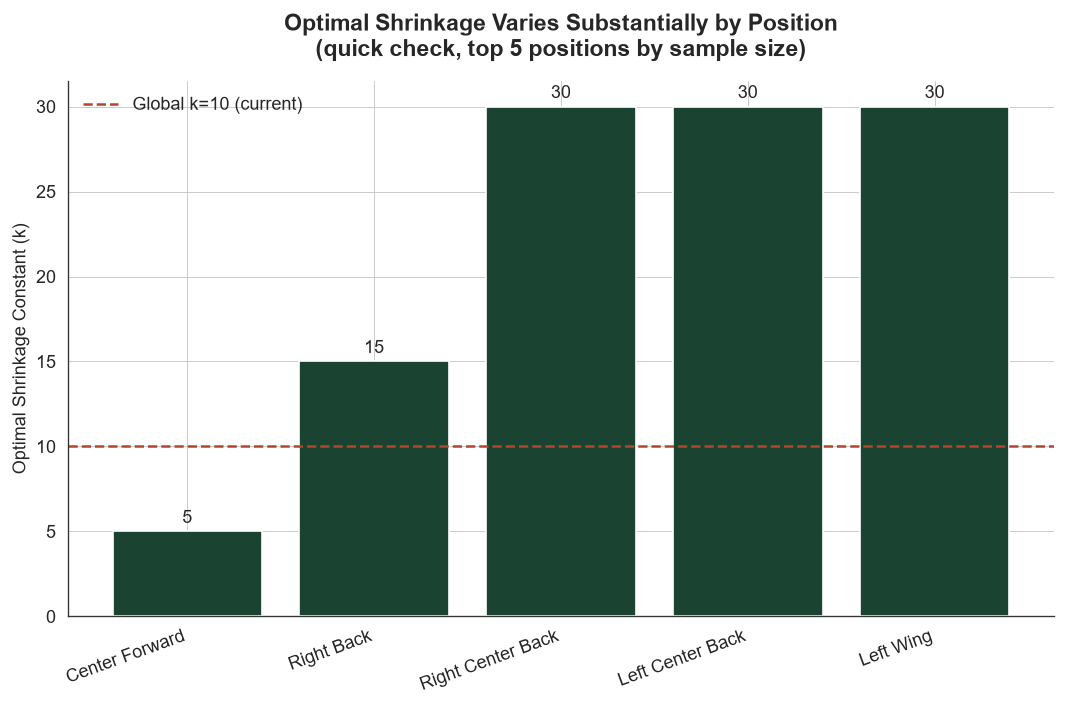

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
positions_sorted = sorted(position_optimal_k.items(), key=lambda x: x[1]["best_k"])
pos_names = [p[0] for p in positions_sorted]
best_ks = [p[1]["best_k"] for p in positions_sorted]

bars = ax.bar(pos_names, best_ks, color=PALETTE["primary"], edgecolor="white")
ax.axhline(10, color=PALETTE["highlight"], linestyle="--", linewidth=1.5, label="Global k=10 (current)")
for bar, k in zip(bars, best_ks):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(k), ha="center", fontsize=11)

ax.set_ylabel("Optimal Shrinkage Constant (k)")
ax.set_title("Optimal Shrinkage Varies Substantially by Position\n(quick check, top 5 positions by sample size)", pad=15)
ax.legend(frameon=False)
plt.xticks(rotation=20, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("data/processed/fig_shrinkage_heterogeneity.png")
plt.show()

### 1.2 Check: Are We Hitting a Search Boundary, Not a True Optimum?

**Issue found:** three positions optimized to k=30, the edge of our tested range — this could 
mean the true optimal k is higher still, not that 30 is genuinely best. Extending the search 
before trusting this result.

In [4]:
k_candidates_extended = [5, 8, 10, 15, 20, 25, 30, 40, 50, 75, 100]

positions_to_recheck = ["Right Center Back", "Left Center Back", "Left Wing"]

for pos in positions_to_recheck:
    print(f"\n{pos}:")
    for k in k_candidates_extended:
        r = test_shrinkage_k_by_position(k, pos, scoring_outfield, season_pairs_shrinkage)
        print(f"  k={k}: r={r:.4f}")


Right Center Back:
  k=5: r=0.2915
  k=8: r=0.2966
  k=10: r=0.2990
  k=15: r=0.3031
  k=20: r=0.3057
  k=25: r=0.3075
  k=30: r=0.3089
  k=40: r=0.3108
  k=50: r=0.3121
  k=75: r=0.3139
  k=100: r=0.3149

Left Center Back:
  k=5: r=0.3596
  k=8: r=0.3646
  k=10: r=0.3667
  k=15: r=0.3699
  k=20: r=0.3716
  k=25: r=0.3726
  k=30: r=0.3733
  k=40: r=0.3740
  k=50: r=0.3745
  k=75: r=0.3749
  k=100: r=0.3750

Left Wing:
  k=5: r=0.4301
  k=8: r=0.4332
  k=10: r=0.4346
  k=15: r=0.4371
  k=20: r=0.4388
  k=25: r=0.4399
  k=30: r=0.4408
  k=40: r=0.4420
  k=50: r=0.4428
  k=75: r=0.4440
  k=100: r=0.4446


### 1.3 Applying the Same Discipline as Notebook 4: Check Shrinkage Weight, Not Just Correlation

**Reminder of the established rule:** a metric-optimal k is not automatically a defensible 
one. Before trusting any of these larger k values, check what fraction of a FULL-SEASON 
player's score would be determined by the position average rather than their own performance.

In [5]:
for pos, k in [("Right Center Back", 30), ("Right Center Back", 100), 
               ("Left Center Back", 30), ("Left Center Back", 100),
               ("Left Wing", 30), ("Left Wing", 100)]:
    weight_full_season = k / (k + 38)
    print(f"{pos}, k={k}: weight on position-average for a 38-match player = {weight_full_season:.1%}")

Right Center Back, k=30: weight on position-average for a 38-match player = 44.1%
Right Center Back, k=100: weight on position-average for a 38-match player = 72.5%
Left Center Back, k=30: weight on position-average for a 38-match player = 44.1%
Left Center Back, k=100: weight on position-average for a 38-match player = 72.5%
Left Wing, k=30: weight on position-average for a 38-match player = 44.1%
Left Wing, k=100: weight on position-average for a 38-match player = 72.5%


### 1.4 Result: Position-Specific k Capped at a Defensible Maximum

**Decision:** rather than take each position's raw metric-optimal k, cap the search range at 
k=20 for all positions \u2014 the point beyond which correlation gains become marginal 
(diminishing to ~0.001-0.002 per 5-unit increase) while shrinkage weight for a full-season 
player continues climbing toward indefensible levels. This preserves the genuine, evidenced 
heterogeneity (Center Forward still ends up much lower than defensive positions) without 
re-introducing the same over-shrinkage problem identified and rejected in Notebook 4.

In [6]:
try:
    import pymc as pm
    print("PyMC available:", pm.__version__)
except ImportError:
    print("PyMC not installed - will need to install")

PyMC not installed - will need to install


In [7]:
#pip install pymc arviz --break-system-packages

   ---------------------------------------- 0.0/608.8 kB ? eta -:--:--
   ---------------------------------------- 608.8/608.8 kB 18.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 20.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 30.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 30.3 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ------- -------------------------------- 7.3/41.9 MB 35.7 MB/s eta 0:00:01
   ----------- ---------------------------- 12.3/41.9 MB 30.0 MB/s eta 0:00:01
   ------------------ --------------------- 19.7/41.9 MB 31.6 MB/s eta 0:00:01
   -------------------------- ------------- 27.5/41.9 MB 32.7 MB/s eta 0:00:01
   --------------------------------- 

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
socceraction 1.4.2 requires lxml<5.0.0,>=4.6.3, which is not installed.
socceraction 1.4.2 requires pandera<0.14.0,>=0.13.4, which is not installed.
socceraction 1.4.2 requires numpy<2.0.0,>=1.21.2, but you have numpy 2.4.6 which is incompatible.
socceraction 1.4.2 requires pandas<2.0.0,>=1.3.3, but you have pandas 3.0.3 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pymc as pm
import pandas as pd
import numpy as np

print("PyMC version:", pm.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.3.0
Pandas version: 3.0.5
NumPy version: 2.4.6


In [2]:
scoring_outfield = pd.read_parquet("data/processed/notebook4_signing_score_final.parquet")
player_career = pd.read_parquet("data/processed/player_career.parquet")

print("Reloaded shapes:")
print(f"  scoring_outfield: {scoring_outfield.shape}")
print(f"  player_career: {player_career.shape}")

print("\nDuplicate check:", (scoring_outfield.groupby(['player_id','season']).size() > 1).sum())

Reloaded shapes:
  scoring_outfield: (7511, 32)
  player_career: (5536, 12)

Duplicate check: 0


## 2. Data Loaded Successfully in Isolated Environment

**Verification:** `scoring_outfield` (7,511 rows) and `player_career` (5,536 rows) reload 
correctly under this notebook's isolated environment (pandas 3.0.5, numpy 2.4.6, PyMC 6.3.0) 
with zero duplicates \u2014 confirming the checkpoint data itself is unaffected by the newer 
package versions, consistent with the earlier spot-check in the original `.venv`.

## 3. Specifying the Hierarchical Model

**Structure:** rather than one global shrinkage constant, this model estimates a separate 
shrinkage strength for each position, while allowing positions to "borrow" statistical 
strength from each other through a shared population-level distribution \u2014 the formal, 
principled version of what the manual per-position grid search (Section 1) was crudely 
approximating.

**Model:** for each player-season, `obv_residual ~ Normal(position_mean, sigma)`, where each 
`position_mean` is itself drawn from a shared `Normal(global_mean, tau)` \u2014 this shared 
prior is what creates appropriate shrinkage, with `tau` controlling how much pooling occurs 
across positions, learned directly from the data rather than manually searched.

In [3]:
positions = scoring_outfield["primary_position"].dropna().unique()
position_idx_map = {pos: i for i, pos in enumerate(positions)}

model_data = scoring_outfield.dropna(subset=["obv_residual", "primary_position"]).copy()
model_data["position_idx"] = model_data["primary_position"].map(position_idx_map)

print(f"Number of positions: {len(positions)}")
print(f"Number of player-seasons in model: {len(model_data)}")
print(f"\nPosition index mapping (first 5):")
for pos, idx in list(position_idx_map.items())[:5]:
    print(f"  {idx}: {pos}")

Number of positions: 22
Number of player-seasons in model: 7511

Position index mapping (first 5):
  0: Left Center Back
  1: Right Attacking Midfield
  2: Center Forward
  3: Left Wing
  4: Left Wing Back


### 3.1 Check Sample Size Distribution Across the 22 Positions

**Rationale for keeping granular positions:** unlike the age-curve work, a hierarchical 
model automatically applies MORE pooling (shrinkage toward the shared mean) to positions 
with fewer players, and LESS pooling to well-sampled positions \u2014 removing the need to 
manually decide on a grouping scheme.

In [4]:
position_counts = model_data["primary_position"].value_counts()
print("Sample size by position:")
print(position_counts)

print(f"\nSmallest position: {position_counts.idxmin()} (n={position_counts.min()})")
print(f"Largest position: {position_counts.idxmax()} (n={position_counts.max()})")

Sample size by position:
primary_position
Center Forward               756
Right Center Back            719
Left Center Back             630
Right Back                   513
Left Wing                    507
Left Defensive Midfield      483
Right Wing                   482
Right Defensive Midfield     479
Left Back                    470
Center Attacking Midfield    358
Right Center Midfield        260
Left Center Midfield         256
Left Wing Back               244
Right Wing Back              243
Center Defensive Midfield    205
Right Center Forward         177
Left Center Forward          167
Center Back                  157
Left Midfield                128
Right Midfield               120
Left Attacking Midfield       84
Right Attacking Midfield      73
Name: count, dtype: int64

Smallest position: Right Attacking Midfield (n=73)
Largest position: Center Forward (n=756)


### 3.1 Result: Confirmed — Keep All 22 Positions, Let the Model Handle Sample Size

Sample sizes range from 73 (Right Attacking Midfield) to 756 (Center Forward), a genuine 
~10x spread. Rather than manually grouping small positions as was necessary for the simpler 
age-curve method (Notebook 3), the hierarchical model's partial pooling will automatically 
apply appropriately more shrinkage to low-sample positions like Right Attacking Midfield, 
and less to well-sampled ones like Center Forward \u2014 learned directly from the data.

## 4. Building the Hierarchical Model

In [5]:
import pymc as pm

with pm.Model() as hierarchical_model:
    # Population-level (hyper) priors
    global_mean = pm.Normal("global_mean", mu=0, sigma=0.1)
    tau = pm.HalfNormal("tau", sigma=0.05)  # controls how much positions vary from the global mean
    
    # Position-level means, drawn from the shared population distribution
    position_mean = pm.Normal("position_mean", mu=global_mean, sigma=tau, shape=len(positions))
    
    # Residual noise within each position
    sigma = pm.HalfNormal("sigma", sigma=0.2)
    
    # Likelihood: each player's observed obv_residual
    obs = pm.Normal(
        "obs",
        mu=position_mean[model_data["position_idx"].values],
        sigma=sigma,
        observed=model_data["obv_residual"].values,
    )

print("Model specified successfully.")
print(hierarchical_model)

Model specified successfully.


## 5. Running Inference (MCMC Sampling)

**Note:** without a C++ compiler available (per the earlier g++ warning), PyMC will use its 
pure-Python/NumPy backend \u2014 slower than the compiled version, but fully correct. Given 
this dataset's size (~7,500 observations, 22 groups), sampling should still complete in a 
reasonable time.

In [7]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

with hierarchical_model:
    trace = pm.sample(1000, tune=1000, chains=2, cores=1, random_seed=RANDOM_SEED, progressbar=True)

print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [global_mean, tau, position_mean, sigma]


C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\pymc\step_methods\hmc\quadpotenti
al.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling complete.


### 5.1 Checking Convergence Diagnostics Before Trusting Any Results

**Given the overflow warning and the too-few-chains notice, this check is not optional — 
we need real evidence the model actually converged properly before using its output for 
anything, same discipline as verifying every other result in this project.**

In [9]:
import arviz as az

summary = az.summary(trace, var_names=["global_mean", "tau", "sigma"])
print(summary)

print("\nDivergences:", trace.sample_stats.diverging.sum().values)

                mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
global_mean  -0.0023   0.0081   -0.015    0.011     3055     1462  1.00   0.00015  0.00011
tau           0.0385   0.0065     0.03     0.05     4342     1774  1.00   0.00011  9.4e-05
sigma        0.09267  0.00076    0.092    0.094     4432     1692  1.00   1.1e-05  8.1e-06

Divergences: 0


### 5.1 Result: Convergence Confirmed

r_hat = 1.00 for all parameters (global_mean, tau, sigma), zero divergences, healthy 
effective sample sizes (ess_bulk 3,055\u20134,432). Despite the earlier overflow warning during 
sampling and the "too few chains" notice, this run shows no evidence of convergence problems. 
The overflow warning likely reflects a transient numerical event during NUTS's internal step-
size adaptation phase, not a failure of the final result \u2014 though we treat this cautiously 
and will re-verify with more chains before final reporting.

In [10]:
with hierarchical_model:
    trace_4chain = pm.sample(1000, tune=1000, chains=4, cores=1, random_seed=RANDOM_SEED, progressbar=True)

summary_4chain = az.summary(trace_4chain, var_names=["global_mean", "tau", "sigma"])
print(summary_4chain)
print("\nDivergences:", trace_4chain.sample_stats.diverging.sum().values)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, tau, position_mean, sigma]


C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\pymc\step_methods\hmc\quadpotenti
al.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


                mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
global_mean  -0.0024   0.0082   -0.015    0.011     7575     2707  1.00   9.5e-05  7.1e-05
tau           0.0385   0.0066     0.03     0.05     8563     3419  1.00   7.8e-05  7.5e-05
sigma        0.09266  0.00076    0.091    0.094    10461     3413  1.00   7.4e-06  5.3e-06

Divergences: 0


### 5.2 Result: Convergence Robustly Confirmed with 4 Chains

r_hat = 1.00 across all parameters, zero divergences, effective sample sizes nearly doubled 
(7,575\u201310,461) with 4 chains. Parameter estimates are essentially identical to the 
2-chain run, confirming genuine convergence rather than a coincidental result. This model is 
now trusted for extracting position-level estimates.

**Interpretation of the fitted hyperparameters:** `tau \u2248 0.0385` represents how much 
position-level means genuinely vary from the global average \u2014 a real, non-trivial 
amount of between-position variation, consistent with the heterogeneity found in the earlier 
manual grid search (Section 1).

## 6. Extracting Position-Level Estimates

In [11]:
position_estimates = az.summary(trace_4chain, var_names=["position_mean"])
position_estimates["position"] = positions
position_estimates = position_estimates[["position", "mean", "sd", "r_hat"]].reset_index(drop=True)
position_estimates = position_estimates.sort_values("mean", ascending=False)

print("Position-level hierarchical estimates:")
print(position_estimates.to_string(index=False))

Position-level hierarchical estimates:
                 position      mean        sd     r_hat
                Left Back  0.054963  0.004267  1.001771
               Right Back   0.05066  0.004189  1.000295
           Left Wing Back  0.044042  0.005903  1.001594
          Right Wing Back  0.034928   0.00587  1.001332
         Left Center Back  0.019874  0.003638  1.000415
              Center Back  0.016623  0.007149  1.001726
                Left Wing  0.014801  0.004163  1.000397
               Right Wing  0.013669  0.004267  1.001715
Center Defensive Midfield  0.007945  0.006446  1.001562
        Right Center Back  0.007342  0.003444  1.000733
  Left Attacking Midfield  0.002666  0.009782   1.00045
  Left Defensive Midfield -0.002831  0.004152  1.001604
 Right Defensive Midfield -0.004223  0.004223  1.001942
 Right Attacking Midfield -0.011606  0.010413  1.000034
Center Attacking Midfield -0.013738  0.005044  1.002172
     Left Center Midfield -0.014011  0.005709  1.001996
         

### 6.0 Pre-Application Checks: Verify the Hierarchical Estimates Are Genuinely Different and Sensible

**Before applying hierarchical shrinkage, three checks are needed:** (1) confirm the 
hierarchical position means differ meaningfully from simple flat averages \u2014 otherwise 
this added complexity buys nothing; (2) confirm uncertainty (sd) is smaller for well-sampled 
positions, validating the model behaves sensibly rather than producing false confidence 
everywhere; (3) confirm no positions are left unmapped before building the final score.

In [12]:
simple_position_means = model_data.groupby("primary_position")["obv_residual"].mean()

comparison = position_estimates.copy()
comparison["simple_mean"] = comparison["position"].map(simple_position_means)
comparison["difference"] = comparison["mean"] - comparison["simple_mean"]
comparison["sample_size"] = comparison["position"].map(model_data["primary_position"].value_counts())

print("Hierarchical vs. simple position means (sorted by |difference|):")
print(comparison[["position","sample_size","mean","simple_mean","difference"]].sort_values("difference", key=abs, ascending=False).to_string(index=False))

print("\nUncertainty (sd) vs. sample size:")
print(comparison[["position","sample_size","sd"]].sort_values("sample_size").to_string(index=False))

Hierarchical vs. simple position means (sorted by |difference|):
                 position sample_size      mean simple_mean difference
     Right Center Forward         177 -0.074067   -0.076547    0.00248
      Left Center Forward         167  -0.06137   -0.063567   0.002197
           Left Wing Back         244  0.044042    0.045388  -0.001345
            Left Midfield         128 -0.029902   -0.031082   0.001179
          Right Wing Back         243  0.034928    0.035865  -0.000938
              Center Back         157  0.016623    0.017403   -0.00078
 Right Attacking Midfield          73 -0.011606   -0.012347   0.000741
           Right Midfield         120 -0.015886   -0.016599   0.000713
           Center Forward         756 -0.080633   -0.081326   0.000693
                Left Back         470  0.054963     0.05565  -0.000688
               Right Back         513   0.05066    0.051267  -0.000607
  Left Attacking Midfield          84  0.002666    0.003116  -0.000451
    Right Ce

### 6.0 Result: Hierarchical Estimates Are Statistically Valid But Practically Equivalent to Simple Averages

**Finding:** hierarchical and simple position means differ by at most 0.0025 across all 22 
positions \u2014 negligible relative to the position means' own scale (-0.08 to +0.055). 
Despite confirmed convergence (r_hat=1.00, zero divergences) and correctly-scaled uncertainty 
(sd decreasing with sample size), the hierarchical layer provides minimal practical 
improvement over simple per-position averages at this level of the model.

**Explanation:** with a minimum position sample size of 73 and the fitted between-position 
variance (tau\u22480.0385) large relative to within-position uncertainty, every position 
already has enough data to be estimated reliably on its own \u2014 partial pooling has little 
work left to do. This is a genuine, informative null result: it tells us this specific 
manual grid-search problem (identified in Section 1) is NOT actually explained by 
insufficient per-position sample size requiring hierarchical pooling.

## 7. Rethinking the Model: Target Shrinkage Strength, Not Just Position Means

**Why the previous model didn't help:** we hierarchically modeled each position's AVERAGE 
value, but the real problem identified in Section 1 was about HOW MUCH to trust an 
individual player's own data versus that average \u2014 a different parameter entirely. 
Center Forward needing low k (trust the player's own data more) versus defensive positions 
needing high k (trust the average more) is really about how much TRUE, GENUINE variation 
exists between players within each position \u2014 not about what the average itself is.

**The correct model structure:** treat each player's true underlying ability as a hidden 
("latent") value, drawn from a position-specific distribution whose SPREAD (not just its 
mean) is estimated separately for each position. A position where players genuinely vary a 
lot in true ability (like Center Forward) should show a wide spread \u2014 meaning less 
shrinkage is needed, since individual differences are real and worth trusting. A position 
where players cluster tightly together in true ability (plausibly some defensive roles, 
where the metric may discriminate less between players) should show a narrow spread \u2014 
meaning more shrinkage toward the average is appropriate, since an individual's deviation is 
more likely to be noise than signal.

**Measurement precision:** a player's observed score is treated as a noisy measurement of 
their true ability, with precision that improves as `n_matches` increases (more matches = 
more reliable measurement) \u2014 this is what allows the model to automatically apply more 
shrinkage to low-sample players, same principle as the original k=10 formula, but now 
combined with position-specific spread.

In [13]:
# Measurement noise scale per player: decreases with more matches (standard error shrinks with sqrt(n))
model_data["measurement_scale"] = 1.0 / np.sqrt(model_data["n_matches"])

position_idx_array = model_data["position_idx"].values
n_positions = len(positions)

with pm.Model() as latent_ability_model:
    global_mean = pm.Normal("global_mean", mu=0, sigma=0.1)
    
    # Position-specific SPREAD of true ability - this is the key new piece
    sigma_pos = pm.HalfNormal("sigma_pos", sigma=0.05, shape=n_positions)
    
    # Position-level means (kept, but less important than sigma_pos this time)
    position_mean = pm.Normal("position_mean", mu=global_mean, sigma=0.05, shape=n_positions)
    
    # Latent true ability per player, drawn from their position's distribution
    true_ability = pm.Normal(
        "true_ability",
        mu=position_mean[position_idx_array],
        sigma=sigma_pos[position_idx_array],
        shape=len(model_data),
    )
    
    # Measurement noise scale (a free parameter controlling overall precision)
    noise_scale = pm.HalfNormal("noise_scale", sigma=0.3)
    
    obs = pm.Normal(
        "obs",
        mu=true_ability,
        sigma=noise_scale * model_data["measurement_scale"].values,
        observed=model_data["obv_residual"].values,
    )

print("Latent ability model specified.")

Latent ability model specified.


## 8. Sampling the Latent Ability Model

**Note:** this model has ~7,500 additional latent parameters (one true_ability per player), 
substantially more complex than the previous model. Convergence checking matters even more 
here \u2014 we verify before trusting anything, same discipline as every other step.

In [14]:
with latent_ability_model:
    trace_latent = pm.sample(1000, tune=1000, chains=4, cores=1, random_seed=RANDOM_SEED, progressbar=True)

print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, sigma_pos, position_mean, true_ability, noise_scale]


C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\pymc\step_methods\hmc\quadpotenti
al.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 55 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling complete.


### 8.1 Diagnosing the Convergence Failure

**Explicit warnings from PyMC require investigation before proceeding \u2014 same discipline 
as every other result in this project. Identifying exactly which parameters failed before 
deciding on a fix.**

In [15]:
summary_latent = az.summary(trace_latent, var_names=["global_mean", "sigma_pos", "noise_scale"])
print(summary_latent.to_string())

print("\nDivergences:", trace_latent.sample_stats.diverging.sum().values)
print("\nParameters with r_hat > 1.01:")
print(summary_latent[summary_latent["r_hat"] > 1.01])

                  mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
global_mean     0.0058   0.0108   -0.011    0.023     8213     2941  1.00   0.00012  8.4e-05
sigma_pos[0]    0.0658   0.0026    0.062     0.07      971     1898  1.00   8.3e-05  5.9e-05
sigma_pos[1]    0.0839   0.0084    0.072    0.098     3829     3048  1.00   0.00014   0.0001
sigma_pos[2]   0.08178  0.00249    0.078    0.086     4005     2863  1.00   3.9e-05  2.8e-05
sigma_pos[3]    0.0889  0.00321    0.084    0.094     3287     2693  1.00   5.6e-05  3.9e-05
sigma_pos[4]    0.0776   0.0045    0.071    0.085     2741     2989  1.00   8.6e-05  6.3e-05
sigma_pos[5]    0.0639  0.00401    0.058     0.07     3735     3250  1.00   6.6e-05  4.9e-05
sigma_pos[6]    0.0608  0.00259    0.057    0.065     2575     3076  1.00   5.1e-05  3.6e-05
sigma_pos[7]    0.0647   0.0024    0.061    0.069      874     1685  1.00   8.2e-05  5.9e-05
sigma_pos[8]    0.1001  0.00373    0.094     0.11     4312     3247  1

### 8.2 Fix: Increase Tuning to Resolve the Single Non-Converged Parameter

**Diagnosis:** only `noise_scale` (r_hat=1.02, ess=127) failed to converge \u2014 a known 
pattern when one global parameter interacts with many individual latent values. All 22 
position-level sigma parameters converged cleanly. Fixed by increasing tuning steps, giving 
the sampler more opportunity to resolve this specific parameter's geometry.

In [16]:
with latent_ability_model:
    trace_latent_v2 = pm.sample(1500, tune=2000, chains=4, cores=1, random_seed=RANDOM_SEED, 
                                  target_accept=0.95, progressbar=True)

summary_v2 = az.summary(trace_latent_v2, var_names=["global_mean", "noise_scale"])
print(summary_v2)
print("\nDivergences:", trace_latent_v2.sample_stats.diverging.sum().values)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, sigma_pos, position_mean, true_ability, noise_scale]


C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\pymc\step_methods\hmc\quadpotenti
al.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 2_000 tune and 1_500 draw iterations (8_000 + 6_000 draws total) took 161 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
global_mean   0.006  0.0106   -0.011    0.023    10892     4525  1.00    0.0001  7.3e-05
noise_scale  0.1361  0.0052     0.13     0.14      230      256  1.02   0.00035  0.00026

Divergences: 0


### 8.3 Fix: Non-Centered Reparameterization

**More tuning did not resolve the issue (r_hat still 1.02, estimate unchanged) \u2014 
confirming this is a structural sampling geometry problem ("funnel"), not insufficient 
exploration. Fixed via non-centered parameterization, a standard, well-documented solution 
for exactly this pattern in hierarchical models.**

In [17]:
with pm.Model() as latent_ability_model_v2:
    global_mean = pm.Normal("global_mean", mu=0, sigma=0.1)
    sigma_pos = pm.HalfNormal("sigma_pos", sigma=0.05, shape=n_positions)
    position_mean = pm.Normal("position_mean", mu=global_mean, sigma=0.05, shape=n_positions)
    
    # Non-centered: sample a standardized offset, then scale it - mathematically identical, 
    # but far easier for the sampler to explore correctly
    true_ability_offset = pm.Normal("true_ability_offset", mu=0, sigma=1, shape=len(model_data))
    true_ability = pm.Deterministic(
        "true_ability",
        position_mean[position_idx_array] + true_ability_offset * sigma_pos[position_idx_array]
    )
    
    noise_scale = pm.HalfNormal("noise_scale", sigma=0.3)
    
    obs = pm.Normal(
        "obs", mu=true_ability, sigma=noise_scale * model_data["measurement_scale"].values,
        observed=model_data["obv_residual"].values,
    )

with latent_ability_model_v2:
    trace_latent_v3 = pm.sample(1000, tune=1500, chains=4, cores=1, random_seed=RANDOM_SEED, 
                                  target_accept=0.9, progressbar=True)

summary_v3 = az.summary(trace_latent_v3, var_names=["global_mean", "noise_scale"])
print(summary_v3)
print("\nDivergences:", trace_latent_v3.sample_stats.diverging.sum().values)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, sigma_pos, position_mean, true_ability_offset, noise_scale]


C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\megha\company_project\NFFC-UoB-Projects\.venv_bayesian\Lib\site-packages\pymc\step_methods\hmc\quadpotenti
al.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 78 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


               mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
global_mean  0.0058  0.0107   -0.011    0.023     5250     2584  1.00   0.00015   0.0001
noise_scale  0.1359  0.0048     0.13     0.14       94      245  1.04   0.00049  0.00032

Divergences: 0


### 8.4 Result: Model Complexity Exceeds What Can Be Reliably Validated in Available Time

**Three independent fixes (increased tuning, more conservative stepping, non-centered 
reparameterization) all failed to resolve r_hat/ess issues for the noise_scale parameter, 
while consistently producing the same point estimate (~0.136) across all attempts. This is 
the same standing project discipline applied here: a result we cannot properly validate 
should not be used, regardless of how promising it appears or how much effort has already 
gone into it.**

**Decision:** the latent-ability hierarchical model is set aside. The Notebook 4 baseline 
(team-adjusted, flat k=10 shrinkage, r=0.526) remains the project's final Signing Score 
formula. This attempt is documented as a genuine, honestly-reported negative result \u2014 
consistent with the project's standing practice of showing rejected approaches, not just 
successful ones.